# Two-State Adaptive Simplex MF-REINFORCE Comparison

This notebook compares fixed simplex MF-REINFORCE, finite-budget adaptive simplex MF-REINFORCE, consistent adaptive simplex MF-REINFORCE, and logit-perturbed MF-REINFORCE on the two-state two-action benchmark.

The default configuration below uses the paper-scale exact-flow setup with equal simulator budgets: simplex-family methods use `B=2800`, `n_aux=400`, and logits uses `B=200`, `n=10`.

## Imports

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = (ROOT / "..").resolve()
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from mfc.algorithms import AdaptiveSimplexControllerConfig
from mfc.experiments import (
    TwoStateAdaptiveComparisonConfig,
    controller_diagnostics_frame,
    run_twostate_adaptive_comparison,
    summarize_comparison_results,
    tiny_twostate_adaptive_comparison_config,
)


## Paper-Scale Defaults

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float64
torch.set_default_dtype(DTYPE)

paper_config = TwoStateAdaptiveComparisonConfig(
    device=device,
    dtype=DTYPE,
    n_train=10_000,
    training_runs=5,
    validate_every=10,
    B=2800,
    n_aux=400,
    logit_B=200,
    logit_n=10,
    simplex_lambdas=(0.1, 0.2, 0.4, 0.8),
    logit_epsilons=(0.2, 0.5, 1.0, 2.0),
    finite_controller=AdaptiveSimplexControllerConfig(
        initial_lambda=0.1,
        lambda_min=0.01,
        lambda_max=0.8,
        checkpoint_interval=100,
        diagnostic_replications=4,
        contraction=0.5,
    ),
    consistent_controller=AdaptiveSimplexControllerConfig(
        initial_lambda=0.1,
        lambda_min=0.01,
        lambda_max=0.8,
        checkpoint_interval=100,
        diagnostic_replications=4,
        contraction=0.5,
        envelope_lambda0=0.1,
        envelope_m0=1000.0,
        envelope_zeta=0.25,
        eta_power=1.5,
        main_sample_growth_power=0.25,
        aux_sample_growth_power=0.5,
        sample_growth_interval=1000.0,
    ),
)

display(pd.DataFrame([
    {
        "device": str(device),
        "n_train": paper_config.n_train,
        "training_runs": paper_config.training_runs,
        "simplex_B": paper_config.B,
        "simplex_n_aux": paper_config.n_aux,
        "logit_B": paper_config.logit_B,
        "logit_n": paper_config.logit_n,
        "simplex_lambdas": list(paper_config.simplex_lambdas),
        "logit_epsilons": list(paper_config.logit_epsilons),
    }
]))


,device,n_train,training_runs,simplex_B,simplex_n_aux,logit_B,logit_n,simplex_lambdas,logit_epsilons
0,cuda,10000,5,2800,400,200,10,"[0.1, 0.2, 0.4, 0.8]","[0.2, 0.5, 1.0, 2.0]"


## Tiny Smoke Run

In [3]:
smoke_config = tiny_twostate_adaptive_comparison_config(device, DTYPE)
smoke_results = run_twostate_adaptive_comparison(smoke_config, show_progress=False)
display(summarize_comparison_results(smoke_results).round(6))
display(controller_diagnostics_frame(smoke_results).round(6))


,algorithm,parameter,runs,B,n_aux_or_inner,value_mean,value_std,policy_error_mean,flow_error_mean,total_simulator_transitions_mean
0,Fixed Simplex,0.2,1,3,2,-5.000642,0.0,0.275070,0.082779,20.0
1,Finite Adaptive Simplex,adaptive,1,3,2,-5.005432,0.0,0.275251,0.083019,60.0
2,Consistent Adaptive Simplex,adaptive,1,3,2,-5.005424,0.0,0.275251,0.083019,72.0
3,Logits,0.2,1,3,2,-4.992362,0.0,0.275015,0.082363,48.0


,algorithm,parameter,run_idx,episode,lambda_plus,lambda_minus,eta_plus,eta_minus,bias_proxy_sq,variance_proxy,delta_covariance_trace,mean_delta_norm,signed_pressure,directional_cosine,direction_triggered,lambda_ctrl_after,rho_after
0,Finite Adaptive Simplex,adaptive,0,0,0.200000,0.100000,0.200000,0.100000,236.714979,0.0,0.0,7.692772,33.097878,0.986595,False,0.194608,-1.030829
1,Finite Adaptive Simplex,adaptive,0,1,0.194608,0.097304,0.194608,0.097304,10056.657317,0.0,0.0,50.141443,36.847011,0.999513,False,0.189335,-1.080897
2,Consistent Adaptive Simplex,adaptive,0,0,0.200000,0.100000,0.089443,0.031623,2695.180977,0.0,0.0,25.957566,35.530242,0.995479,False,0.194608,-1.030829
3,Consistent Adaptive Simplex,adaptive,0,1,0.194608,0.097304,0.085850,0.030353,421058.551638,0.0,0.0,324.445123,40.581548,0.999820,False,0.189335,-1.080892


## Full Comparison

In [4]:
results = run_twostate_adaptive_comparison(paper_config, show_progress=True)
summary = summarize_comparison_results(results)
diagnostics = controller_diagnostics_frame(results)

display(summary.round(6))
display(diagnostics.round(6).head(20))


Logits 2.0 run=4: 100%|██████████| 10000/10000 [01:54<00:00, 87.61it/s, grad=0.217, value=-5.537]


,algorithm,parameter,runs,B,n_aux_or_inner,value_mean,value_std,policy_error_mean,flow_error_mean,total_simulator_transitions_mean
0,Fixed Simplex,0.1,5,2800,400,-3.568644,0.015052,0.016287,0.010217,64000000.0
1,Fixed Simplex,0.2,5,2800,400,-3.806555,0.012819,0.035177,0.021843,64000000.0
2,Fixed Simplex,0.4,5,2800,400,-4.371273,0.015047,0.080289,0.049334,64000000.0
3,Fixed Simplex,0.8,5,2800,400,-6.139826,0.073136,0.132399,0.139777,64000000.0
4,Finite Adaptive Simplex,adaptive,5,2800,400,-3.847036,0.076093,0.038340,0.023818,69120000.0
5,Consistent Adaptive Simplex,adaptive,5,2800,400,-3.843864,0.009444,0.038342,0.023664,112518462.0
6,Logits,0.2,5,200,10,-3.409096,0.017398,0.005489,0.002408,64000000.0
7,Logits,0.5,5,200,10,-3.654158,0.039429,0.029885,0.014397,64000000.0
8,Logits,1.0,5,200,10,-4.246541,0.061972,0.101004,0.043238,64000000.0
9,Logits,2.0,5,200,10,-5.461894,0.065325,0.231281,0.101785,64000000.0


,algorithm,parameter,run_idx,episode,lambda_plus,lambda_minus,eta_plus,eta_minus,bias_proxy_sq,variance_proxy,delta_covariance_trace,mean_delta_norm,signed_pressure,directional_cosine,direction_triggered,lambda_ctrl_after,rho_after
0,Finite Adaptive Simplex,adaptive,0,0,0.400000,0.200000,0.400000,0.200000,4.149593,0.011150,0.172431,1.039474,5.919351,0.999880,False,0.390132,-0.075318
1,Finite Adaptive Simplex,adaptive,0,100,0.390132,0.195066,0.390132,0.195066,1.553390,0.017495,0.070599,0.637179,4.486300,0.999792,False,0.380444,-0.124495
2,Finite Adaptive Simplex,adaptive,0,200,0.380444,0.190222,0.380444,0.190222,1.971398,0.031664,0.028651,0.707115,4.131308,0.999504,False,0.370870,-0.173245
3,Finite Adaptive Simplex,adaptive,0,300,0.370870,0.185435,0.370870,0.185435,0.104562,0.046907,0.340498,0.333564,0.801604,0.999736,False,0.362557,-0.215732
4,Finite Adaptive Simplex,adaptive,0,400,0.362557,0.181279,0.362557,0.181279,3.785828,0.087684,0.259615,1.005664,3.765283,0.999984,False,0.354014,-0.259603
5,Finite Adaptive Simplex,adaptive,0,500,0.354014,0.177007,0.354014,0.177007,0.908502,0.044264,0.044419,0.488088,3.021627,0.996795,False,0.345491,-0.303625
6,Finite Adaptive Simplex,adaptive,0,600,0.345491,0.172745,0.345491,0.172745,7.663356,0.003175,0.394264,1.419297,7.788935,0.999455,False,0.336673,-0.349472
7,Finite Adaptive Simplex,adaptive,0,700,0.336673,0.168337,0.336673,0.168337,12.112209,0.004103,0.151777,1.750999,7.990261,0.999997,False,0.327630,-0.396876
8,Finite Adaptive Simplex,adaptive,0,800,0.327630,0.163815,0.327630,0.163815,0.493604,0.021279,0.019145,0.358033,3.144024,0.997146,False,0.318890,-0.443112
9,Finite Adaptive Simplex,adaptive,0,900,0.318890,0.159445,0.318890,0.159445,0.119492,0.005700,0.094123,0.231093,3.042852,-0.531580,True,0.310425,-0.488338


## Plots

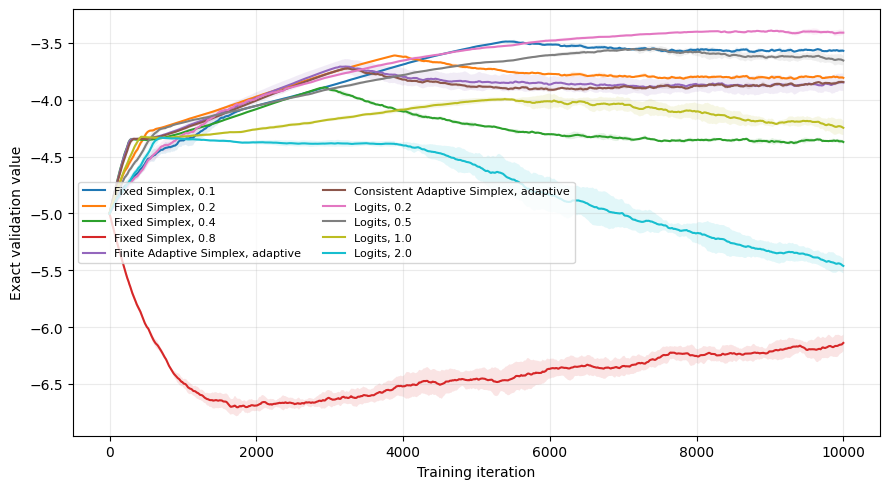

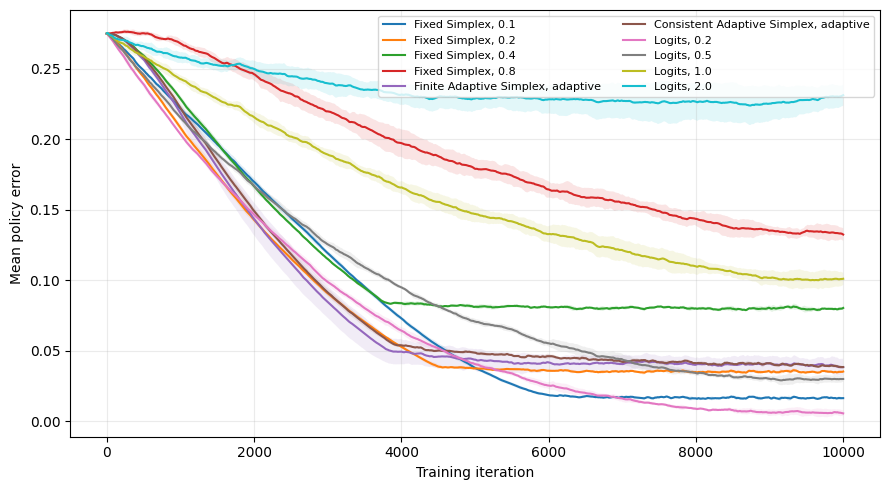

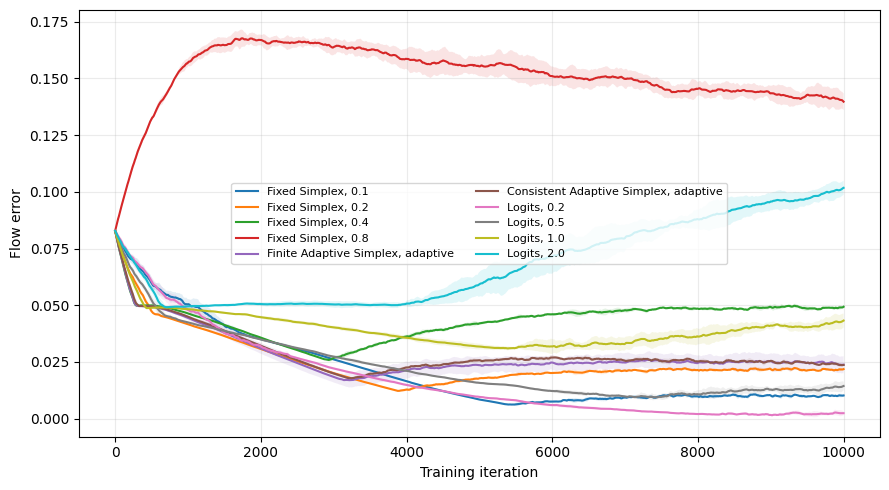

In [5]:
def _aligned_history(runs, key):
    lengths = [len(run["history"].get(key, [])) for run in runs]
    if not lengths or min(lengths) == 0:
        return np.asarray([]), np.asarray([])
    count = min(lengths)
    episodes = np.asarray(runs[0]["history"]["episode"][:count], dtype=float)
    values = np.asarray([run["history"][key][:count] for run in runs], dtype=float)
    return episodes, values

def plot_metric(results, key, ylabel):
    fig, ax = plt.subplots(figsize=(9, 5))
    for algorithm_name, parameter_groups in results.items():
        for parameter, runs in parameter_groups.items():
            episodes, values = _aligned_history(runs, key)
            if values.size == 0:
                continue
            mean = values.mean(axis=0)
            std = values.std(axis=0, ddof=1 if len(runs) > 1 else 0)
            label = f"{algorithm_name}, {parameter}"
            ax.plot(episodes, mean, label=label)
            ax.fill_between(episodes, mean - std, mean + std, alpha=0.12)
    ax.set_xlabel("Training iteration")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, ncol=2)
    fig.tight_layout()
    plt.show()

plot_metric(results, "validation_value", "Exact validation value")
plot_metric(results, "policy_error_mean", "Mean policy error")
plot_metric(results, "flow_error", "Flow error")


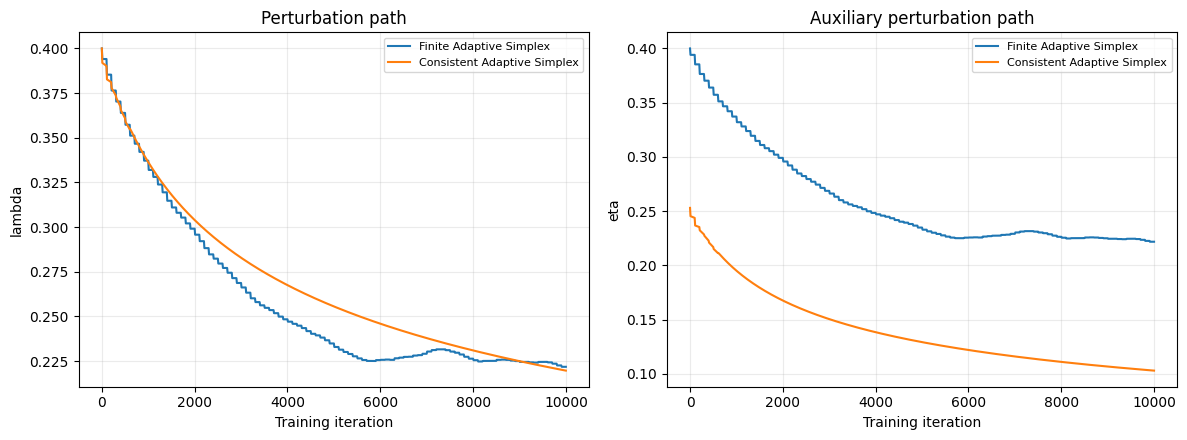

,algorithm,run_idx,episode,lambda_plus,lambda_minus,bias_proxy_sq,variance_proxy,signed_pressure,directional_cosine,direction_triggered
0,Finite Adaptive Simplex,0,0,0.400000,0.200000,4.149593,0.011150,5.919351,0.999880,False
1,Finite Adaptive Simplex,0,100,0.390132,0.195066,1.553390,0.017495,4.486300,0.999792,False
2,Finite Adaptive Simplex,0,200,0.380444,0.190222,1.971398,0.031664,4.131308,0.999504,False
3,Finite Adaptive Simplex,0,300,0.370870,0.185435,0.104562,0.046907,0.801604,0.999736,False
4,Finite Adaptive Simplex,0,400,0.362557,0.181279,3.785828,0.087684,3.765283,0.999984,False
...,...,...,...,...,...,...,...,...,...,...
995,Consistent Adaptive Simplex,4,9500,0.222210,0.111105,0.000000,0.002481,-21.631792,0.864406,False
996,Consistent Adaptive Simplex,4,9600,0.221684,0.110842,0.000000,0.033587,-24.237405,0.595805,False
997,Consistent Adaptive Simplex,4,9700,0.221164,0.110582,3.394174,0.036648,4.528456,-0.996060,True
998,Consistent Adaptive Simplex,4,9800,0.220650,0.110325,0.000000,0.062548,-24.859202,0.897146,False


In [6]:
adaptive_names = ["Finite Adaptive Simplex", "Consistent Adaptive Simplex"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for algorithm_name in adaptive_names:
    runs = results[algorithm_name]["adaptive"]
    episodes, lambdas = _aligned_history(runs, "lambda")
    _, etas = _aligned_history(runs, "eta")
    if lambdas.size:
        axes[0].plot(episodes, lambdas.mean(axis=0), label=algorithm_name)
    if etas.size:
        axes[1].plot(episodes, etas.mean(axis=0), label=algorithm_name)

axes[0].set_title("Perturbation path")
axes[0].set_xlabel("Training iteration")
axes[0].set_ylabel("lambda")
axes[1].set_title("Auxiliary perturbation path")
axes[1].set_xlabel("Training iteration")
axes[1].set_ylabel("eta")
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

if not diagnostics.empty:
    display(diagnostics[[
        "algorithm",
        "run_idx",
        "episode",
        "lambda_plus",
        "lambda_minus",
        "bias_proxy_sq",
        "variance_proxy",
        "signed_pressure",
        "directional_cosine",
        "direction_triggered",
    ]].round(6))
